# Independent Single-band GP Baseline

In [1]:
%load_ext autoreload
%autoreload 2
from datasets import load_dataset
from data_processing import process_one_obj_one_band, process_one_obj_one_band_train_heldout, split_train_heldout_observations, select_examples_and_global_flux_scale
from singleGP_model import (
    fit_basic_gp,
    evaluate_heldout_nlpd,
    evaluate_heldout_rmse,
    evaluate_heldout_metrics,
    summarize_object_metric_results,
    standardized_residual_statistics,
    yerr_statistics,
    largest_standardized_residual_cases,
    print_largest_standardized_residual_cases,
    cover_factor,
)
from visualization import plot_gp_fit, plot_largest_standardized_residual_cases

dset_plasticc = load_dataset("MultimodalUniverse/plasticc",
                       streaming=True,
                       split='train')
dset_plasticc = dset_plasticc.with_format("numpy")

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


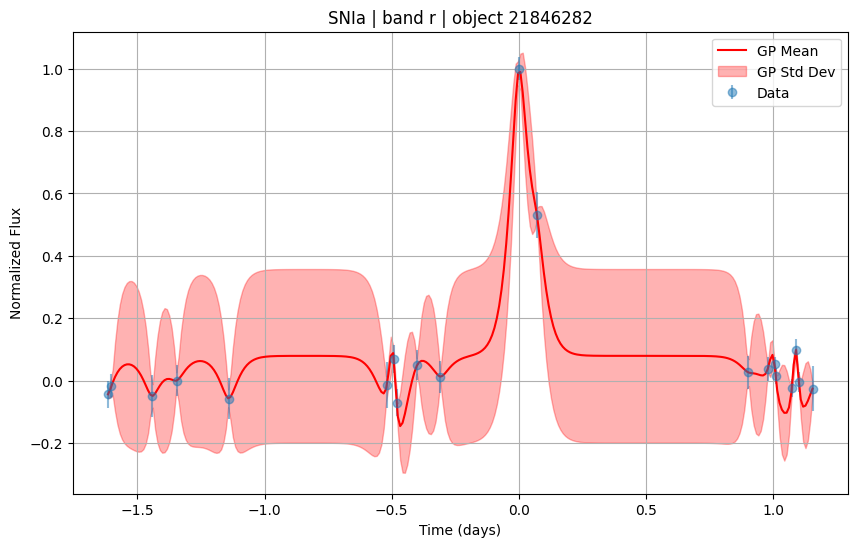

In [3]:
example = next(iter(dset_plasticc))

data = process_one_obj_one_band(example, target_band='r')
if data is not None:
    gp = fit_basic_gp(data, kernel_type="matern")
    plot_gp_fit(gp, data)

## Multi-objects on one band

Unconstrained Matern:kernel = ConstantKernel(1.0) * Matern(length_scale=0.3, nu=1.5)
And higher noise:0.3

In [8]:
import numpy as np

prepared_objects = []

dset_iterator = iter(dset_plasticc)

for i, example in zip(range(500), dset_iterator):
    data = process_one_obj_one_band(
        example,
        target_band="r",
        align_peak=True,
        normalize_flux=True,
        min_points=8,
    )

    if data is not None:
        prepared_objects.append(data)
        print(np.min(data["yerr"]), np.median(data["yerr"]), np.max(data["yerr"]))

print("number of usable objects:", len(prepared_objects))

0.023923717 0.044506773 0.07394759
0.050455526 0.08186242 0.1243165
0.09897589 0.15759754 0.25484547
0.00036992045 0.0006143678 0.005009557
0.02172172 0.047246072 0.07114961
0.03311875 0.06707094 0.11008544
0.010196236 0.022302518 0.04054288
0.032263555 0.06865703 0.10954704
0.034623444 0.10556647 0.16789038
0.033959974 0.06508212 0.11091445
0.026309019 0.05469425 0.10455511
0.039679497 0.06941345 0.117931455
0.0036056964 0.00885603 0.015104389
0.0014955392 0.00448307 0.008963429
0.015701331 0.03085626 0.056639303
0.010919944 0.018603384 0.03727177
0.008556754 0.020484606 0.034463428
0.029406933 0.046728224 0.0890774
0.048371464 0.09180884 0.19809304
0.079814166 0.14818762 0.2264985
0.019528441 0.031279325 0.06783643
0.037351232 0.057684824 0.10662571
0.05415431 0.09277719 0.1547873
0.5313289 0.69672406 1.5314168
0.01587348 0.021993928 0.053439878
0.07077617 0.092653766 0.20290491
0.20072089 0.3292376 0.71703434
0.04184459 0.06628788 0.09637488
0.017610611 0.028007723 0.04016513
0.0322

In [17]:
from GP_model import extract_basic_gp_features

features = []
labels = []

for data in prepared_objects:   # Iterate over each prepared object
    gp = fit_basic_gp(data, kernel_type="matern")
    feat = extract_basic_gp_features(gp, data)
    features.append([feat['peak_flux'], feat['peak_time'], feat['decay_slope'], feat['mean_uncertainty']])
    labels.append(data['obj_type'])

X_features = np.array(features)
y_labels = np.array(labels)

print(X_features.shape)
print(y_labels.shape)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

(500, 4)
(500,)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [11]:
for idx, data in enumerate(prepared_objects[:20]):
    gp = fit_basic_gp(data)
    print(idx, data["obj_id"], data["obj_type"], gp.kernel_)

0 21846282 SNIa 1.14**2 * Matern(length_scale=0.0423, nu=1.5)
1 114421739 AGN 1.03**2 * Matern(length_scale=0.301, nu=1.5)
2 30652072 SNII 0.946**2 * Matern(length_scale=0.0472, nu=1.5)
3 107732897 TDE 0.777**2 * Matern(length_scale=0.103, nu=1.5)
4 121186562 AGN 1.05**2 * Matern(length_scale=0.0393, nu=1.5)
5 10905347 SNII 1.07**2 * Matern(length_scale=0.0293, nu=1.5)
6 16775731 SNIa 0.801**2 * Matern(length_scale=0.046, nu=1.5)
7 31971611 SNII 1.01**2 * Matern(length_scale=0.0746, nu=1.5)
8 50875482 SNIbc 1.09**2 * Matern(length_scale=0.0341, nu=1.5)
9 52437992 AGN 1.07**2 * Matern(length_scale=0.0823, nu=1.5)
10 100164081 SLSN-I 1.23**2 * Matern(length_scale=0.0389, nu=1.5)
11 6777396 AGN 0.948**2 * Matern(length_scale=0.0242, nu=1.5)
12 56002762 SNII 0.887**2 * Matern(length_scale=0.207, nu=1.5)
13 93866109 SNIbc 1.11**2 * Matern(length_scale=0.137, nu=1.5)
14 31725628 SNII 1.11**2 * Matern(length_scale=0.0427, nu=1.5)
15 41660164 SNIbc 1.19**2 * Matern(length_scale=0.0681, nu=1.5)

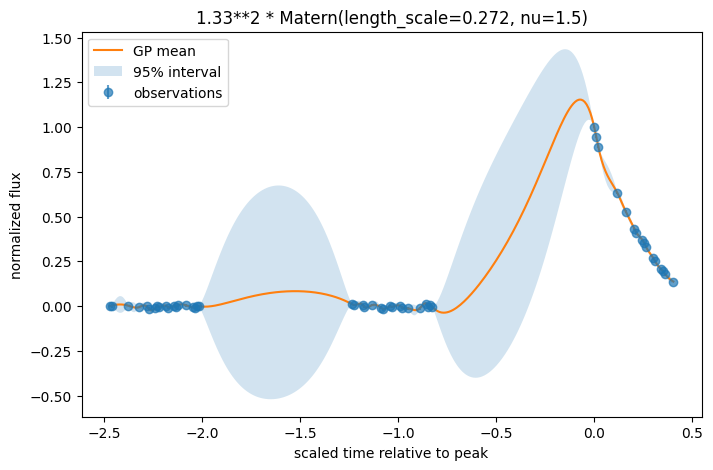

In [9]:
import matplotlib.pyplot as plt
def plot_gp_diagnostic(gp, data, n_grid=300):
    t = data["t"]
    y = data["y"]
    yerr = data["yerr"]

    t_grid = np.linspace(t.min(), t.max(), n_grid)
    X_grid = t_grid.reshape(-1, 1)

    mean, std = gp.predict(X_grid, return_std=True)

    plt.figure(figsize=(8, 5))
    plt.errorbar(t, y, yerr=yerr, fmt="o", alpha=0.7, label="observations")
    plt.plot(t_grid, mean, label="GP mean")
    plt.fill_between(t_grid, mean - 2*std, mean + 2*std, alpha=0.2, label="95% interval")
    plt.xlabel("scaled time relative to peak")
    plt.ylabel("normalized flux")
    plt.title(str(gp.kernel_))
    plt.legend()
    plt.show()
plot_gp_diagnostic(gp, data)

/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

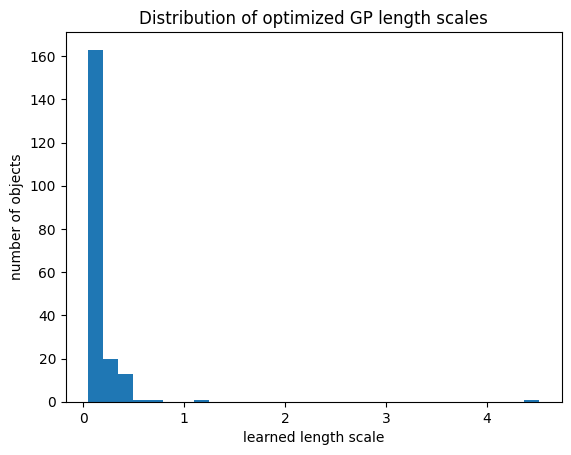

In [18]:
ells = []

for data in prepared_objects[:200]:
    gp = fit_basic_gp(data)

    params = gp.kernel_.get_params()

    if "k2__length_scale" in params:
        ell = params["k2__length_scale"]
        ells.append(ell)
    else:
        print("Could not find length scale for kernel:", gp.kernel_)

plt.hist(ells, bins=30)
plt.xlabel("learned length scale")
plt.ylabel("number of objects")
plt.title("Distribution of optimized GP length scales")
plt.show()

In [20]:
print("median ell:", np.median(ells))
print("min ell:", np.min(ells))
print("max ell:", np.max(ells))
print("fraction near lower bound:", np.mean(np.array(ells) <= 0.051))

median ell: 0.0638863908216447
min ell: 0.05000000000000001
max ell: 4.516997073610352
fraction near lower bound: 0.455


### Constrained Matern:

In [13]:
features = []
labels = []

for data in prepared_objects:   # Iterate over each prepared object
    gp = fit_basic_gp(data, kernel_type="matern")
    feat = extract_basic_gp_features(gp, data)
    features.append([feat['peak_flux'], feat['peak_time'], feat['decay_slope'], feat['mean_uncertainty']])
    labels.append(data['obj_type'])

X_features = np.array(features)
y_labels = np.array(labels)

print(X_features.shape)
print(y_labels.shape)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

(500, 4)
(500,)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [19]:
for idx, data in enumerate(prepared_objects[:20]):
    gp = fit_basic_gp(data)
    print(idx, data["obj_id"], data["obj_type"], gp.kernel_)

/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


0 21846282 SNIa 1.2**2 * Matern(length_scale=0.05, nu=1.5)
1 114421739 AGN 1.03**2 * Matern(length_scale=0.321, nu=1.5)
2 30652072 SNII 0.951**2 * Matern(length_scale=0.05, nu=1.5)
3 107732897 TDE 0.772**2 * Matern(length_scale=0.0999, nu=1.5)
4 121186562 AGN 1.14**2 * Matern(length_scale=0.05, nu=1.5)
5 10905347 SNII 1.13**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

6 16775731 SNIa 0.828**2 * Matern(length_scale=0.05, nu=1.5)
7 31971611 SNII 1.01**2 * Matern(length_scale=0.0751, nu=1.5)
8 50875482 SNIbc 1.23**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


9 52437992 AGN 1.08**2 * Matern(length_scale=0.0864, nu=1.5)
10 100164081 SLSN-I 1.34**2 * Matern(length_scale=0.05, nu=1.5)
11 6777396 AGN 1.13**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


12 56002762 SNII 0.888**2 * Matern(length_scale=0.209, nu=1.5)
13 93866109 SNIbc 1.08**2 * Matern(length_scale=0.136, nu=1.5)
14 31725628 SNII 1.11**2 * Matern(length_scale=0.288, nu=1.5)
15 41660164 SNIbc 1.2**2 * Matern(length_scale=0.0781, nu=1.5)
16 43441391 TDE 1.14**2 * Matern(length_scale=0.105, nu=1.5)
17 46741316 SNIa 1.39**2 * Matern(length_scale=0.05, nu=1.5)
18 56383332 SNIax 0.893**2 * Matern(length_scale=0.0727, nu=1.5)
19 26794348 SNII 1.39**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

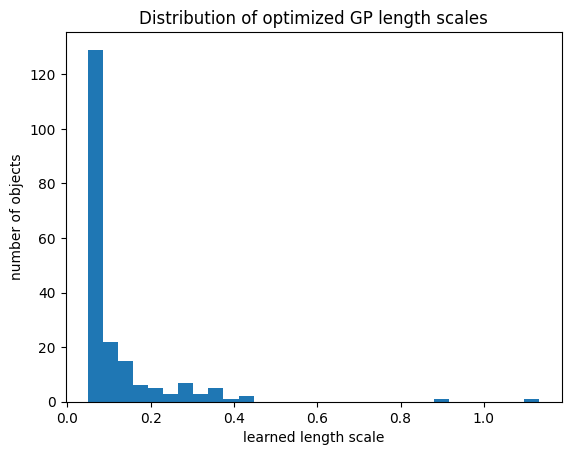

In [15]:
ells = []

for data in prepared_objects[:200]:
    gp = fit_basic_gp(data)

    params = gp.kernel_.get_params()

    if "k2__length_scale" in params:
        ell = params["k2__length_scale"]
        ells.append(ell)
    else:
        print("Could not find length scale for kernel:", gp.kernel_)

plt.hist(ells, bins=30)
plt.xlabel("learned length scale")
plt.ylabel("number of objects")
plt.title("Distribution of optimized GP length scales")
plt.show()

constrained Matérn optimization still tends to choose very short length scales as well

## Fixed length scale experiment

ell = 0.1
kernel after fit: 1**2 * Matern(length_scale=0.1, nu=1.5)


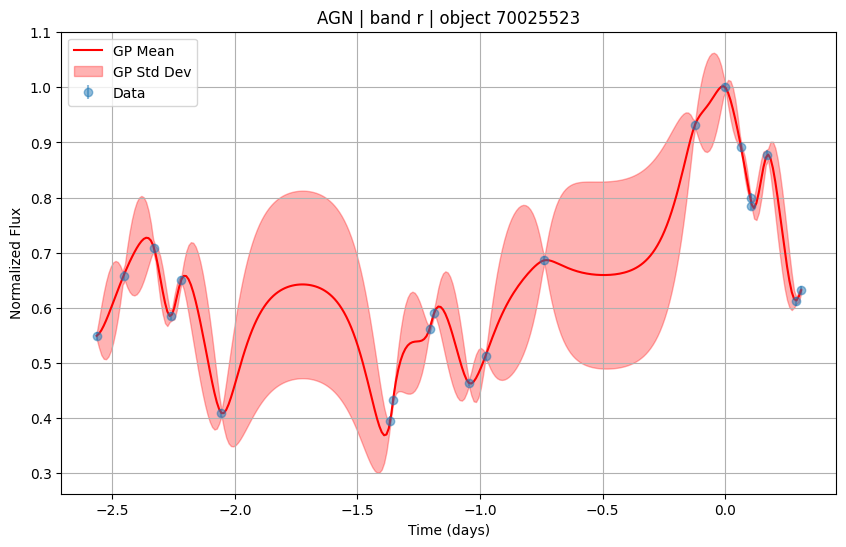

ell = 0.3
kernel after fit: 1**2 * Matern(length_scale=0.3, nu=1.5)


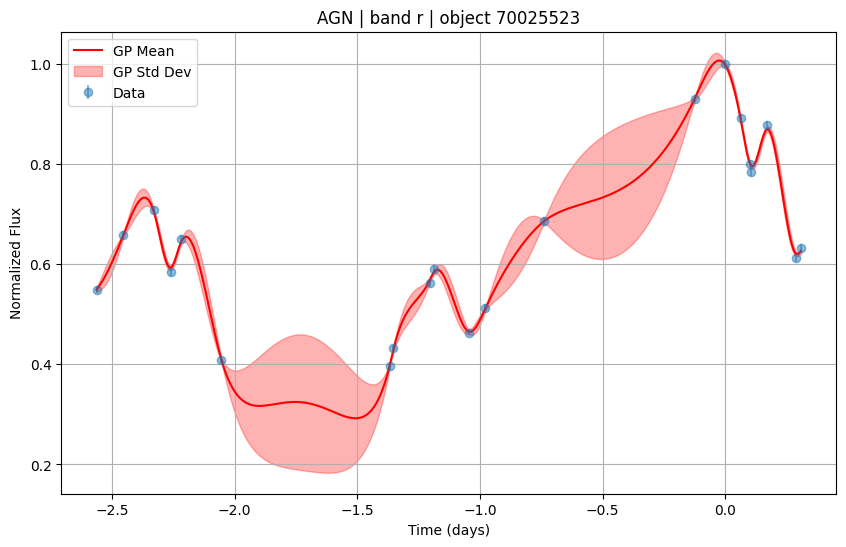

ell = 0.5
kernel after fit: 1**2 * Matern(length_scale=0.5, nu=1.5)


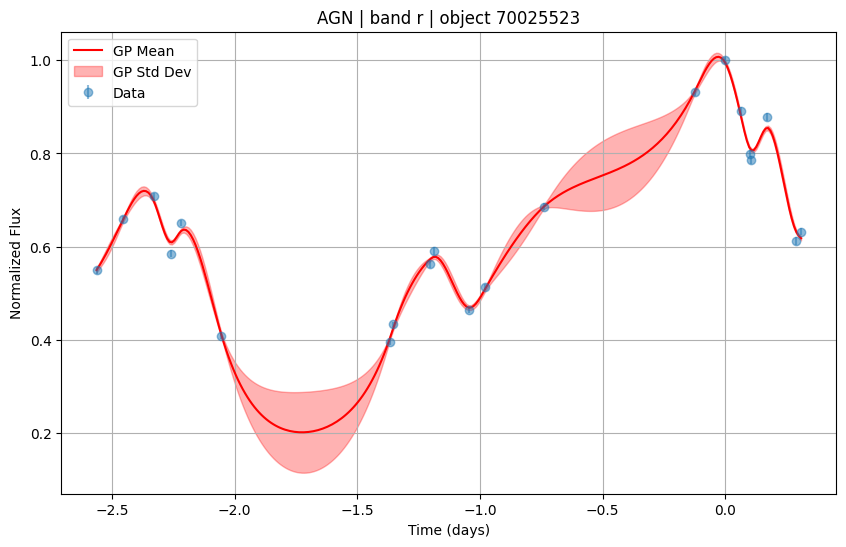

ell = 1.0
kernel after fit: 1**2 * Matern(length_scale=1, nu=1.5)


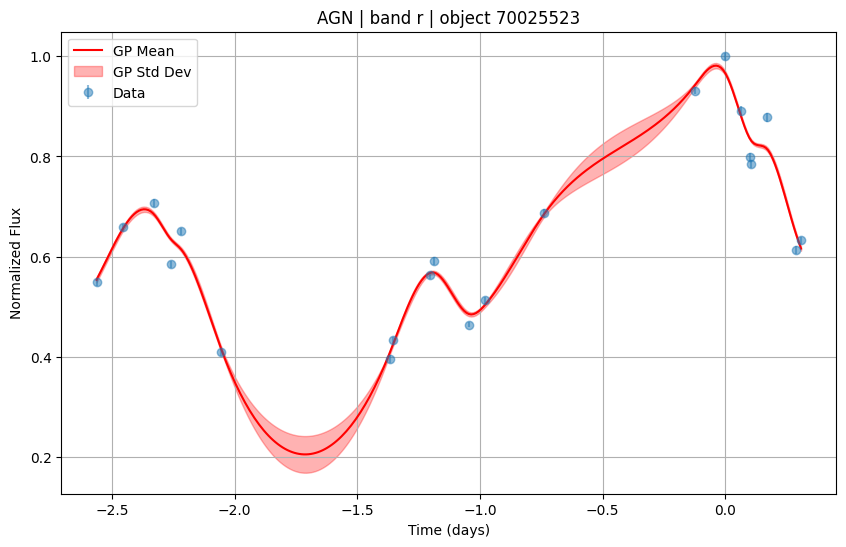

In [13]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
# Find the optimal length scale for the Matern kernel across the first 200 objects
data = prepared_objects[101]
for ell in [0.1, 0.3, 0.5, 1.0]:
    kernel = ConstantKernel(1.0) * Matern(length_scale=ell, nu=1.5)

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=data["yerr"]**2 + 0.03**2 + 1e-6,
        normalize_y=True,
        optimizer=None,
    )

    gp.fit(data["X"], data["y"])
    print("ell =", ell)
    print("kernel after fit:", gp.kernel_)

    plot_gp_fit(gp, data)

## NLPD Evaluation
-- Negative log predictive density

In [3]:

plasticc_iter = iter(dset_plasticc)

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


NLPD: -0.6152701723790499
RMSE: 0.14738226025767603
Coverage:
k=1 0.75
k=2 1.0
k=3 1.0


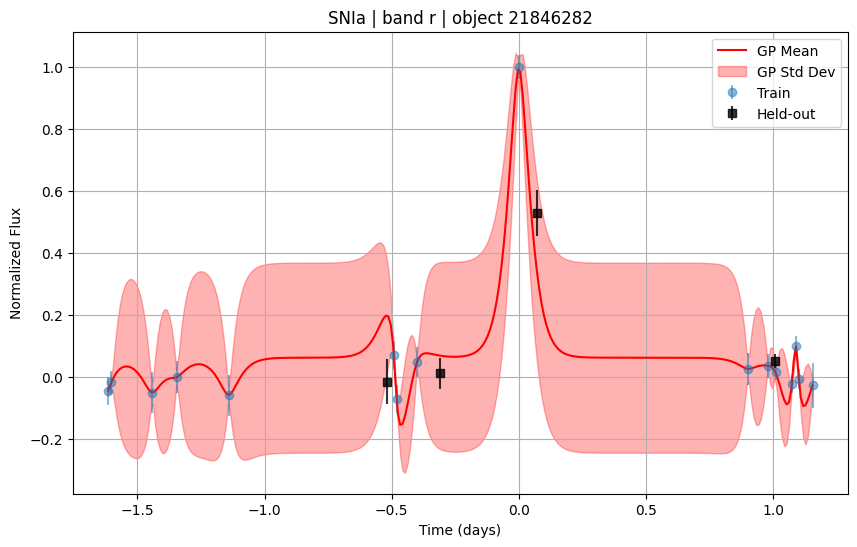

In [4]:
example = next(plasticc_iter)
data = process_one_obj_one_band(example, target_band='r')
train_data, heldout_data = split_train_heldout_observations(
    data,
    heldout_fraction=0.2,
    random_state=0,
    strategy="random",  # or "last"
)

gp = fit_basic_gp(train_data, kernel_type="matern")
nlpd = evaluate_heldout_nlpd(gp, heldout_data)
rmse = evaluate_heldout_rmse(gp, heldout_data)
coverage1 = cover_factor(gp, heldout_data, sigma_multiplier=1.0)
coverage2 = cover_factor(gp, heldout_data, sigma_multiplier=2.0)
coverage3 = cover_factor(gp, heldout_data, sigma_multiplier=3.0)

print("NLPD:", nlpd["mean_nlpd"])
print("RMSE:", rmse["rmse"])
print("Coverage:")
print("k=1", coverage1)   # ~68% for a well-calibrated model
print("k=2", coverage2)   # ~95% for a well-calibrated model
print("k=3", coverage3)   # ~99% for a well-calibrated model
plot_gp_fit(gp, train_data, heldout_data=heldout_data)


## Average Metrics Across Many Objects

Compute observation-weighted and object-weighted averages for NLPD, RMSE, and coverage.


In [2]:
n_objects_target = 300
max_examples_to_scan = 3000
target_band = "r"
global_flux_percentile = 99
min_points = 8
yerr_scale = 1.0
noise_floor = 0.0

selected_examples, flux_scale, scanned_examples = select_examples_and_global_flux_scale(
    iter(dset_plasticc),
    target_band=target_band,
    n_objects=n_objects_target,
    max_examples_to_scan=max_examples_to_scan,
    percentile=global_flux_percentile,
    min_points=min_points,
)

object_results1 = []
object_results2 = []
object_results3 = []
object_results4 = []

failed_objects = 0

for object_idx, example in enumerate(selected_examples):
    try:
        train_data, heldout_data = process_one_obj_one_band_train_heldout(
            example,
            flux_scale=flux_scale,
            target_band=target_band,
            align_peak=True,
            peak_alignment="target_abs_peak",
            peak_mode="absolute",
            force_peak_in_train=False,
            normalize_flux=True,
            min_points=min_points,
            heldout_fraction=0.2,
            min_train_points=5,
            min_heldout_points=1,
            random_state=object_idx,
            strategy="random",
        )
        if train_data is None or heldout_data is None:
            continue

        # fixed length scale to prevent optimization issues
        gp1 = fit_basic_gp(
            train_data,
            kernel_type="matern",
            length_scale=0.3,
            length_scale_bounds="fixed",
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )

        # fixed both length scale and constant value to prevent optimization issues
        gp2 = fit_basic_gp(
            train_data,
            kernel_type="matern",
            length_scale=0.3,
            length_scale_bounds="fixed",
            constant_value=1.0,
            constant_value_bounds="fixed",
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )  

        # fixed only the constant value to see if it helps with calibration
        gp3 = fit_basic_gp(
            train_data,
            kernel_type="matern",
            constant_value=1.0,
            constant_value_bounds="fixed",
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )

        # don't fix anything and let it optimize to see how it performs and if it fails more often
        gp4 = fit_basic_gp(
            train_data,
            kernel_type="matern",
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )

        metrics1 = evaluate_heldout_metrics(
            gp1,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )

        metrics2 = evaluate_heldout_metrics(
            gp2,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )

        metrics3 = evaluate_heldout_metrics(
            gp3,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )

        metrics4 = evaluate_heldout_metrics(
            gp4,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )

        metrics1["obj_id"] = train_data["obj_id"]
        metrics1["obj_type"] = train_data["obj_type"]
        metrics1["gp"] = gp1
        metrics1["train_data"] = train_data
        metrics1["heldout_data"] = heldout_data
        object_results1.append(metrics1)

        metrics2["obj_id"] = train_data["obj_id"]
        metrics2["obj_type"] = train_data["obj_type"]
        metrics2["gp"] = gp2
        metrics2["train_data"] = train_data
        metrics2["heldout_data"] = heldout_data
        object_results2.append(metrics2)

        metrics3["obj_id"] = train_data["obj_id"]
        metrics3["obj_type"] = train_data["obj_type"]
        metrics3["gp"] = gp3
        metrics3["train_data"] = train_data
        metrics3["heldout_data"] = heldout_data
        object_results3.append(metrics3)

        metrics4["obj_id"] = train_data["obj_id"]
        metrics4["obj_type"] = train_data["obj_type"]
        metrics4["gp"] = gp4
        metrics4["train_data"] = train_data
        metrics4["heldout_data"] = heldout_data
        object_results4.append(metrics4)

    except Exception as err:
        failed_objects += 1
        continue

summary1 = summarize_object_metric_results(object_results1)
summary2 = summarize_object_metric_results(object_results2)
summary3 = summarize_object_metric_results(object_results3)
summary4 = summarize_object_metric_results(object_results4)



/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn

In [3]:
print(f"stream examples scanned: {scanned_examples}")
print(f"selected usable objects: {len(selected_examples)}")
print(f"global {global_flux_percentile}th percentile flux scale: {flux_scale:.6g}")
print(f"usable objects evaluated: {summary1['n_objects']}")
print(f"total held-out observations: {summary1['n_heldout_total']}")
print(f"failed fits/splits skipped: {failed_objects}")

print("\nObservation-weighted average")
print("Model 1: fixed length scale")
for metric, value in summary1["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 2: fixed length scale and constant value")
for metric, value in summary2["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 3: fixed constant value")
for metric, value in summary3["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 4: no fixed hyperparameters")
for metric, value in summary4["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")

print("\nObject-weighted average")
print("Model 1: fixed length scale")
for metric, value in summary1["object_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 2: fixed length scale and constant value")
for metric, value in summary2["object_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 3: fixed constant value")
for metric, value in summary3["object_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 4: no fixed hyperparameters")
for metric, value in summary4["object_weighted"].items():
    print(f"{metric}: {value:.4f}")

stream examples scanned: 300
selected usable objects: 300
global 99th percentile flux scale: 868.272
usable objects evaluated: 300
total held-out observations: 1538
failed fits/splits skipped: 0

Observation-weighted average
Model 1: fixed length scale
nlpd: -1.9290
rmse: 0.4389
coverage_1sigma: 0.8296
coverage_2sigma: 0.9415
coverage_3sigma: 0.9662
Model 2: fixed length scale and constant value
nlpd: 2.4585
rmse: 0.2496
coverage_1sigma: 0.9577
coverage_2sigma: 0.9766
coverage_3sigma: 0.9824
Model 3: fixed constant value
nlpd: -0.5608
rmse: 0.2354
coverage_1sigma: 0.7347
coverage_2sigma: 0.9070
coverage_3sigma: 0.9499
Model 4: no fixed hyperparameters
nlpd: -0.1626
rmse: 0.2764
coverage_1sigma: 0.7302
coverage_2sigma: 0.9070
coverage_3sigma: 0.9532

Object-weighted average
Model 1: fixed length scale
nlpd: -1.9395
rmse: 0.0750
coverage_1sigma: 0.8286
coverage_2sigma: 0.9417
coverage_3sigma: 0.9668
Model 2: fixed length scale and constant value
nlpd: 2.3154
rmse: 0.0604
coverage_1sigma:

Model 2 is the most rigid one and correspondingly has the worst performace. 
For Model 1,3,4:
The 1st coverage is often too high or near ideal, 
2nd and 3rd coverage is too low. It's likely that the Gaussian predictive distribution is not capturing the tail behavior of the errors.

Hence, we investigate the standardized residuals.

## Standardized Residual Diagnostics

Pool held-out predictions across all selected objects and compute `z = (y_test - y_mean) / y_std`.


In [4]:
model_results = {
    "Model 1: fixed length scale": object_results1,
    "Model 2: fixed length scale and constant value": object_results2,
    "Model 3: fixed constant value": object_results3,
    "Model 4: no fixed hyperparameters": object_results4,
}

for model_name, results in model_results.items():
    stats = standardized_residual_statistics(results)
    print(f"\n{model_name}")
    print("mean z:", stats["mean_z"])
    print("std z:", stats["std_z"])
    print("1σ:", stats["coverage_1sigma"])
    print("2σ:", stats["coverage_2sigma"])
    print("3σ:", stats["coverage_3sigma"])
    print("max |z|:", stats["max_abs_z"])
    print("95% |z|:", stats["p95_abs_z"])
    print("99% |z|:", stats["p99_abs_z"])



Model 1: fixed length scale
mean z: -0.06292472030346492
std z: 1.4782252450296849
1σ: 0.8296488946684005
2σ: 0.94148244473342
3σ: 0.9661898569570871
max |z|: 28.443231682367962
95% |z|: 2.1816815761594017
99% |z|: 5.631014176002699

Model 2: fixed length scale and constant value
mean z: 0.0003037633401512945
std z: 2.7973875819962823
1σ: 0.9577373211963589
2σ: 0.976592977893368
3σ: 0.982444733420026
max |z|: 71.65584677440394
95% |z|: 0.8885257885543586
99% |z|: 10.382578001201145

Model 3: fixed constant value
mean z: -0.04233169795218366
std z: 2.3999669378769357
1σ: 0.7347204161248374
2σ: 0.9070221066319896
3σ: 0.9499349804941483
max |z|: 40.36059097550419
95% |z|: 2.9862584751694956
99% |z|: 9.230480191672834

Model 4: no fixed hyperparameters
mean z: 0.05139127455829095
std z: 2.583924172849488
1σ: 0.7301690507152145
2σ: 0.9070221066319896
3σ: 0.953185955786736
max |z|: 41.94035015246739
95% |z|: 2.7553143844463404
99% |z|: 9.11105778899578


## Measurement Error Diagnostics

Inspect normalized held-out `yerr` values and whether the worst residuals have unusually small errors.


In [5]:
for model_name, results in model_results.items():
    stats = yerr_statistics(results)
    print(f"\n{model_name}")
    for key, value in stats.items():
        print(f"{key}: {value:.6g}")


Model 1: fixed length scale
min_yerr: 0.00136552
median_yerr: 0.00386311
mean_yerr: 0.00481868
p95_yerr: 0.00806497
max_yerr: 0.0579118
median_yerr_top_1pct_abs_z: 0.00466579
median_yerr_top_5pct_abs_z: 0.00479327

Model 2: fixed length scale and constant value
min_yerr: 0.00136552
median_yerr: 0.00386311
mean_yerr: 0.00481868
p95_yerr: 0.00806497
max_yerr: 0.0579118
median_yerr_top_1pct_abs_z: 0.0400634
median_yerr_top_5pct_abs_z: 0.00804504

Model 3: fixed constant value
min_yerr: 0.00136552
median_yerr: 0.00386311
mean_yerr: 0.00481868
p95_yerr: 0.00806497
max_yerr: 0.0579118
median_yerr_top_1pct_abs_z: 0.00472555
median_yerr_top_5pct_abs_z: 0.00457471

Model 4: no fixed hyperparameters
min_yerr: 0.00136552
median_yerr: 0.00386311
mean_yerr: 0.00481868
p95_yerr: 0.00806497
max_yerr: 0.0579118
median_yerr_top_1pct_abs_z: 0.0045872
median_yerr_top_5pct_abs_z: 0.00421579


## Largest Standardized Residual Cases

Print and plot the held-out points with the largest absolute standardized residuals for each model.



Model 1: fixed length scale
object_id: 34866353 band: r time: -1.351556 X_test: [-1.351556] y: -3.5218093 mean: 0.6328321044129019 std: 0.14606784103621007 z: -28.443231682367962 yerr: 0.032469682 outside_train_range: False near_peak: False n_train: 17
object_id: 100122518 band: r time: -0.44499442 X_test: [-0.44499442] y: -1.6556299 mean: 0.005723645132064803 std: 0.08852301579241376 z: -18.767475368255543 yerr: 0.041306566 outside_train_range: False near_peak: False n_train: 20
object_id: 24400626 band: r time: -0.14534263 X_test: [-0.14534263] y: 0.8204072 mean: 0.17928417873083144 std: 0.05760043456988879 z: 11.130524237136054 yerr: 0.0054080975 outside_train_range: False near_peak: True n_train: 18
object_id: 104025081 band: r time: -0.028832143 X_test: [-0.02883214] y: 0.05557176 mean: 0.1730281236796284 std: 0.011425434254832476 z: -10.280253693436142 yerr: 0.003262501 outside_train_range: False near_peak: True n_train: 23
object_id: 44307163 band: r time: 0.010291234 X_test: [

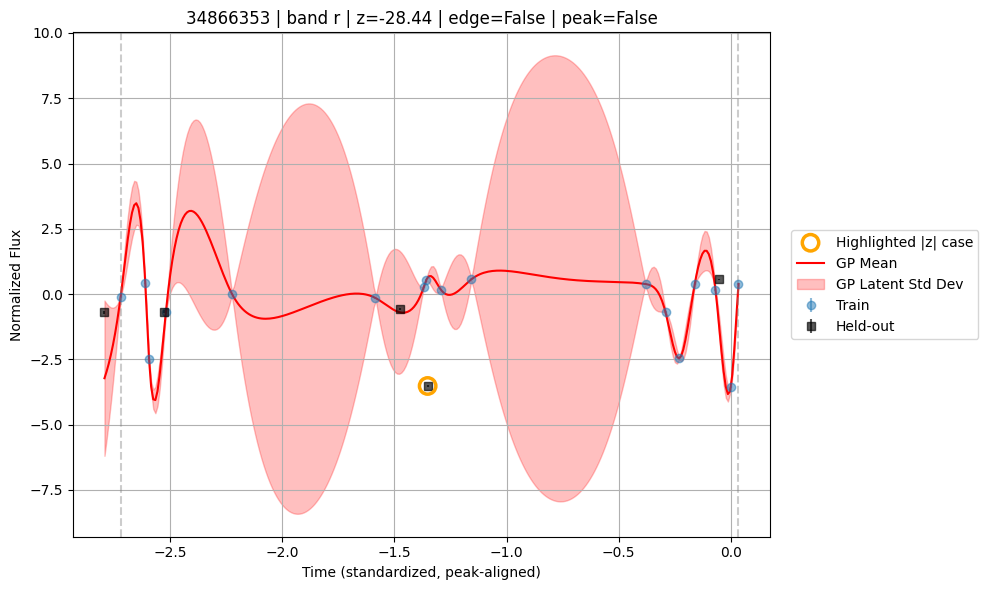

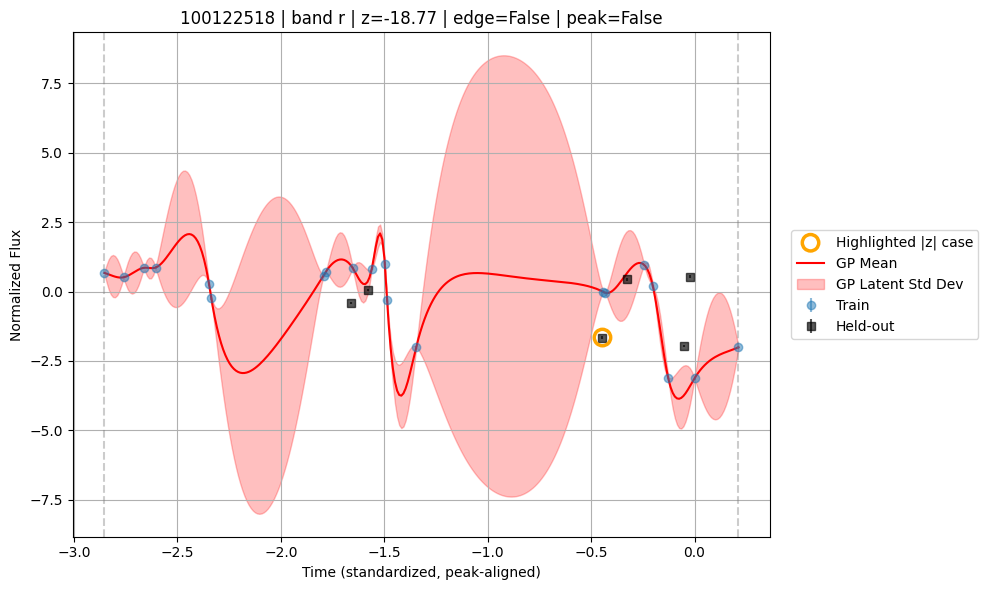

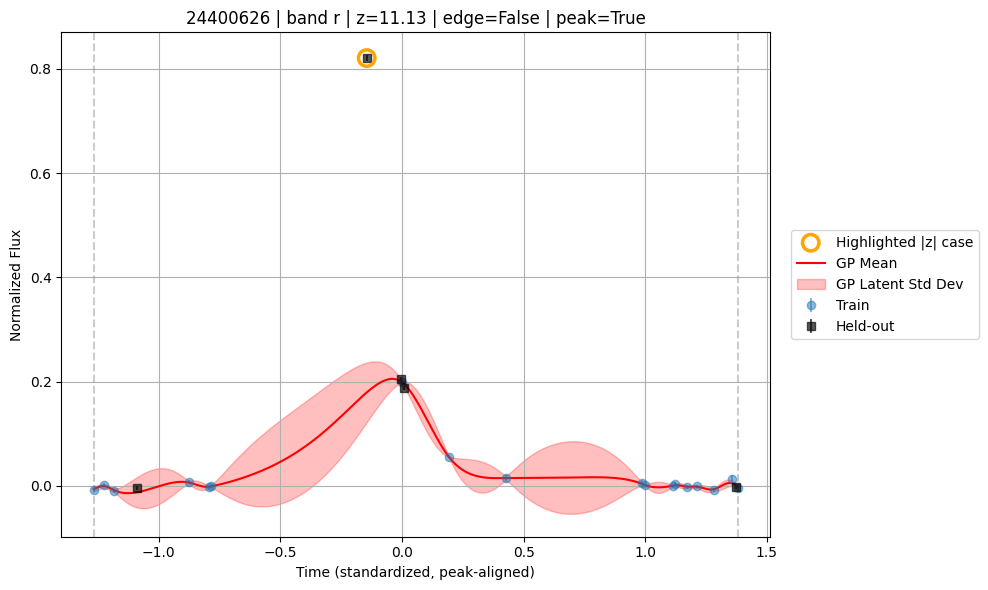

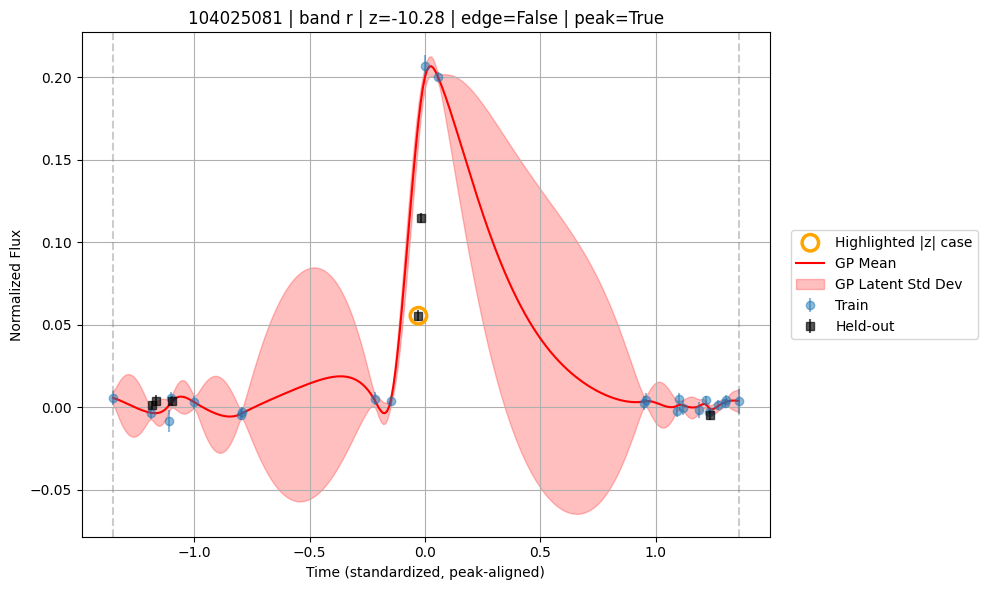

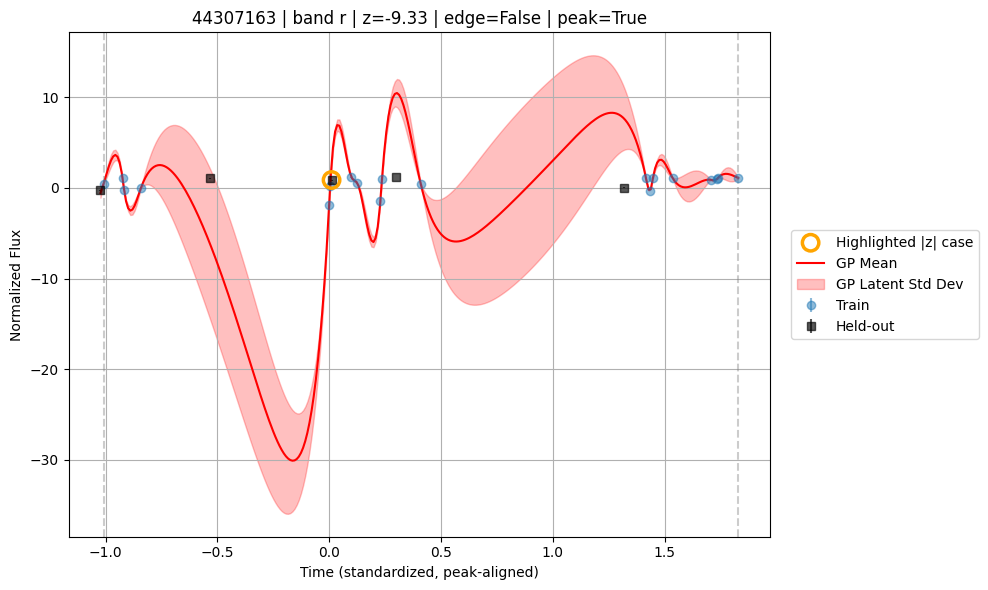


Plots for Model 2: fixed length scale and constant value


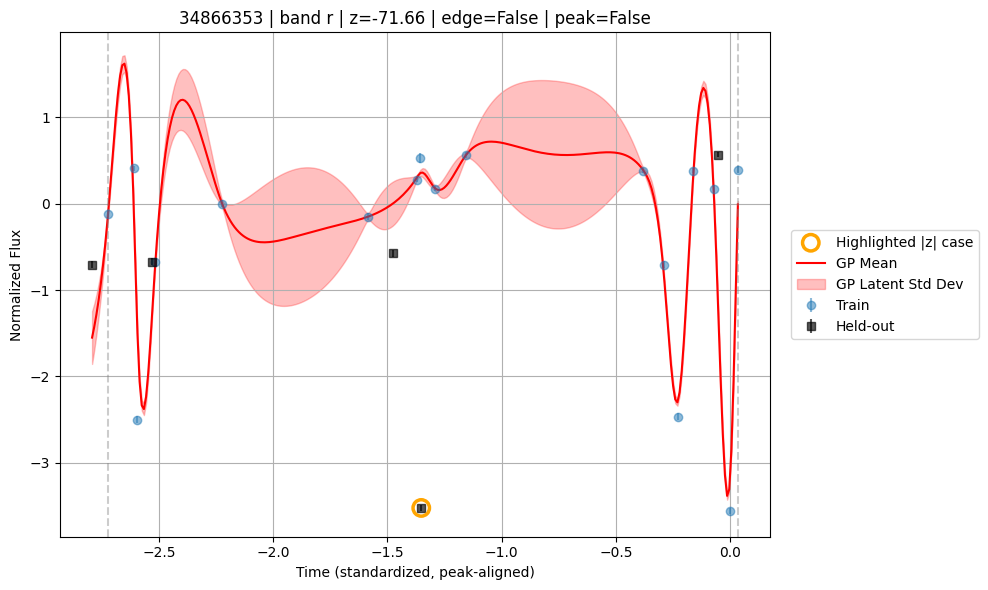

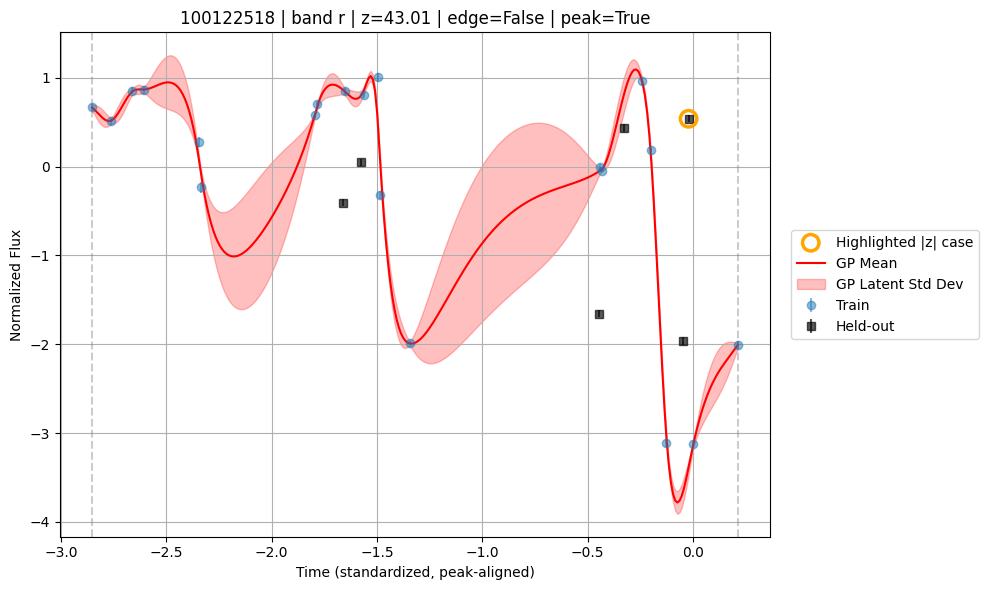

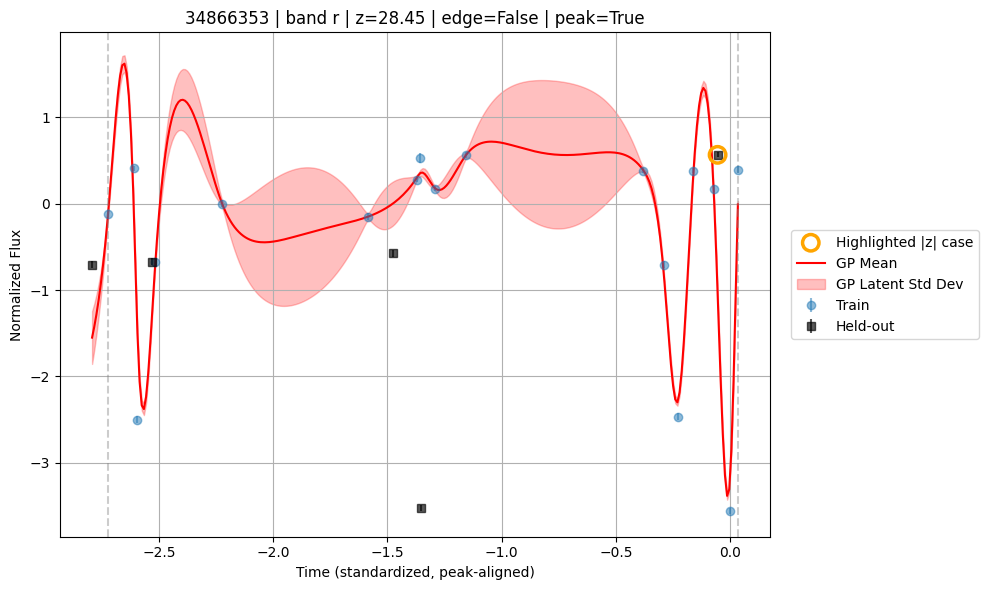

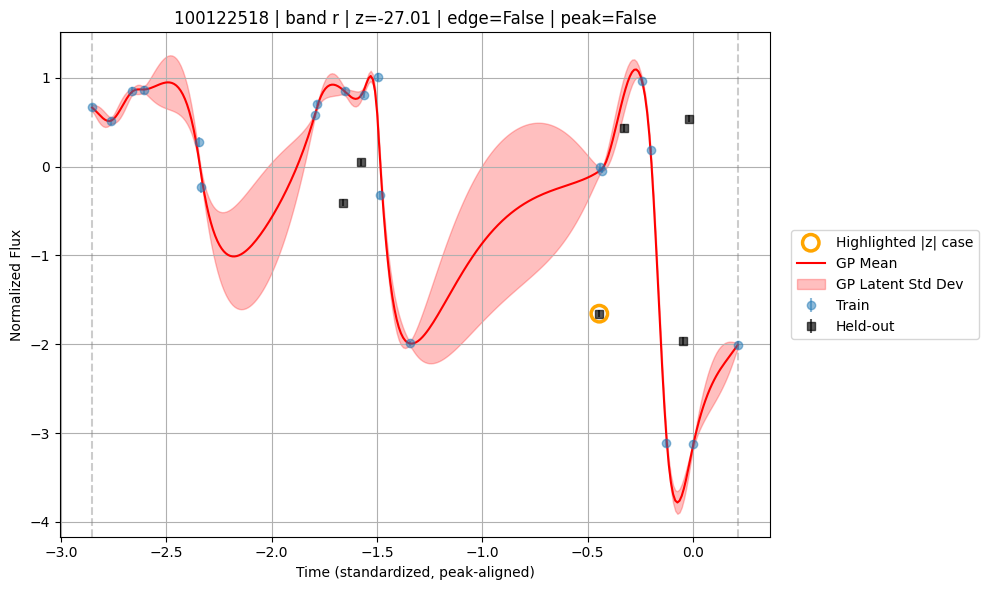

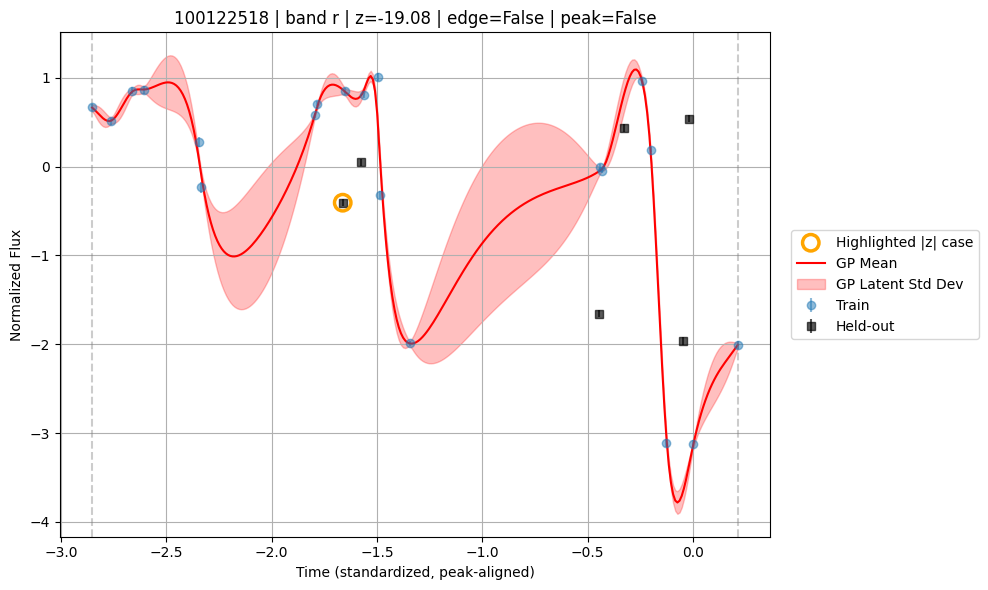


Plots for Model 3: fixed constant value


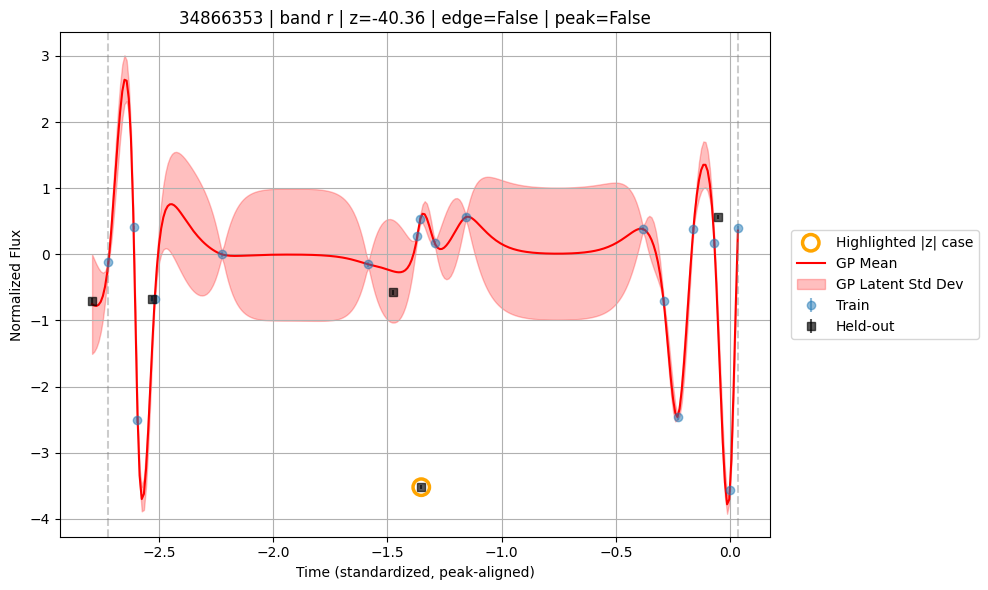

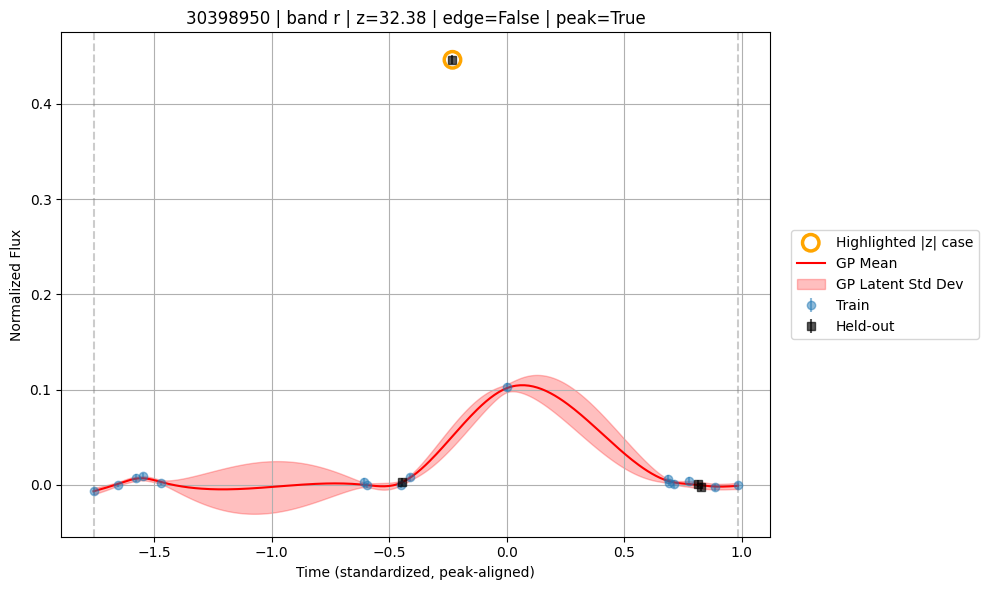

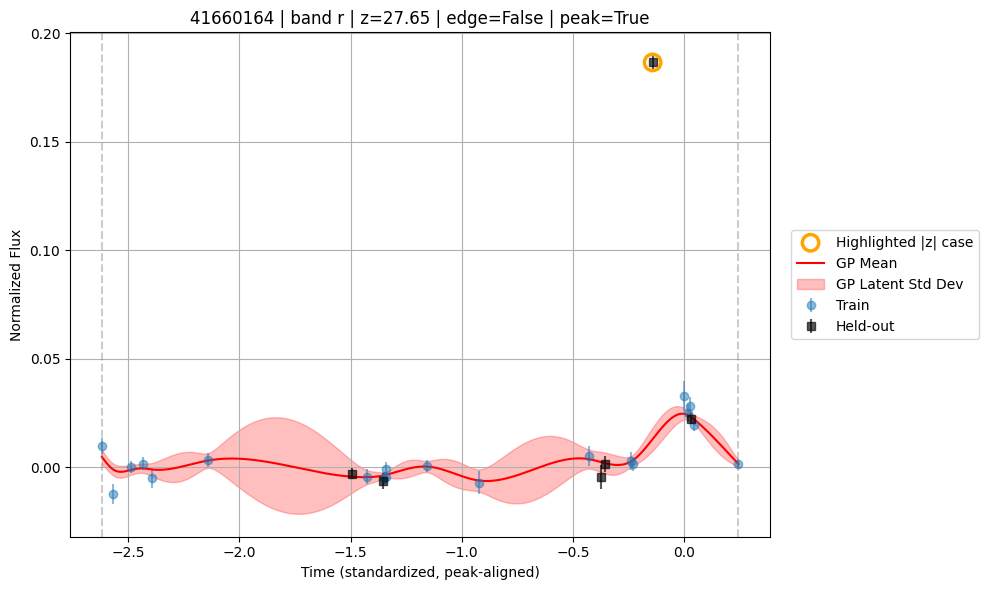

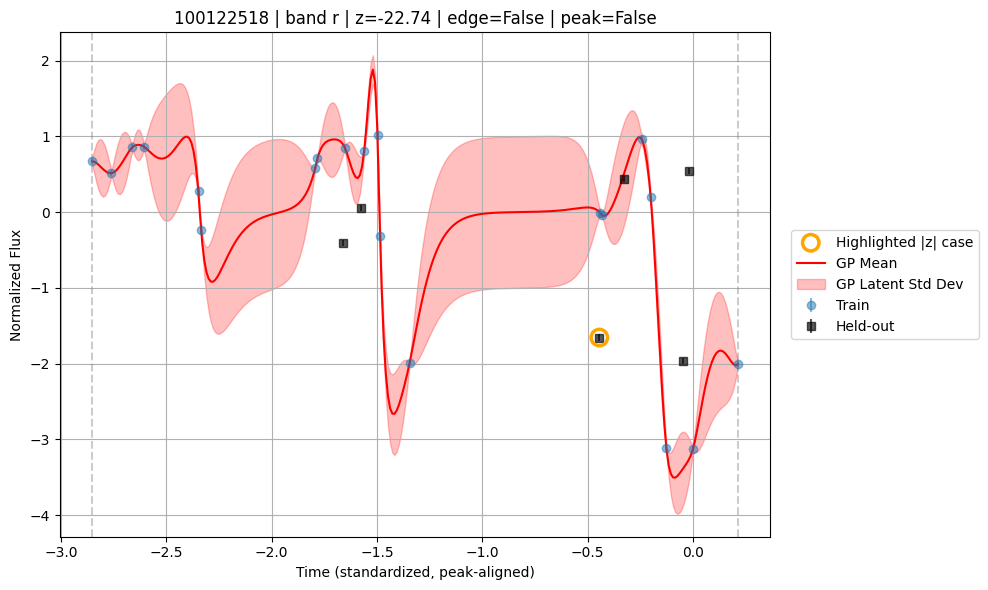

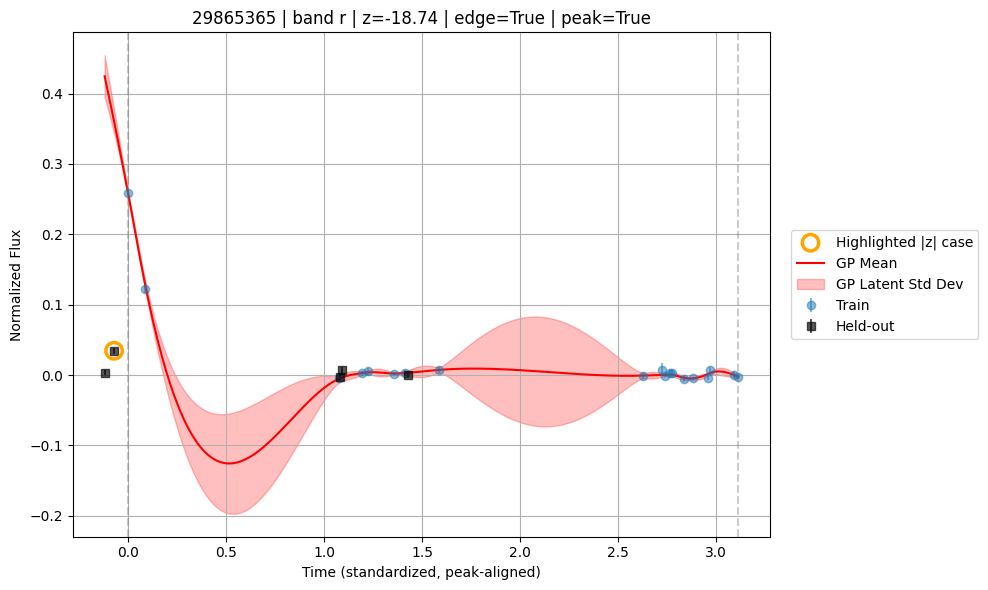


Plots for Model 4: no fixed hyperparameters


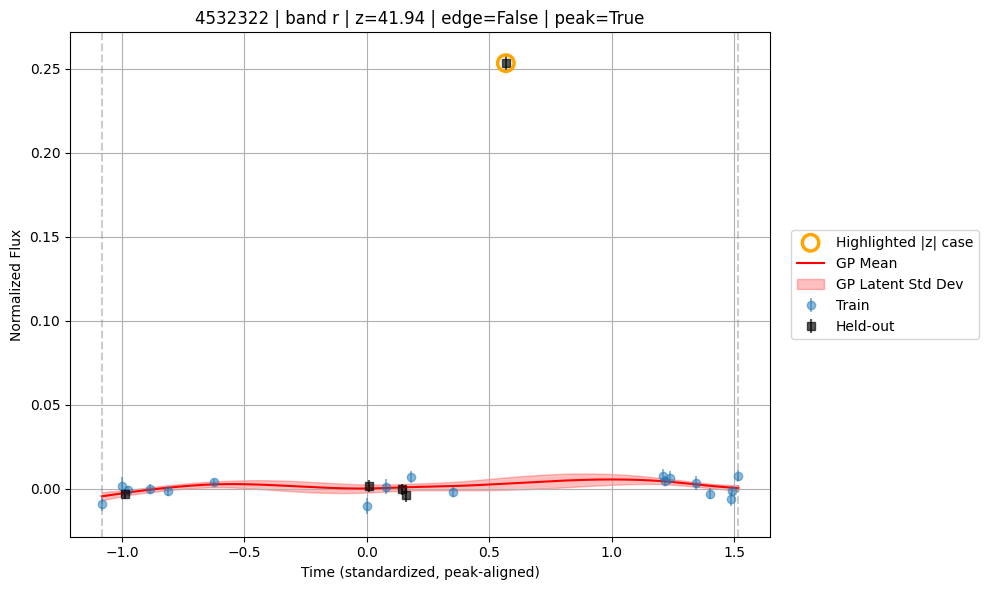

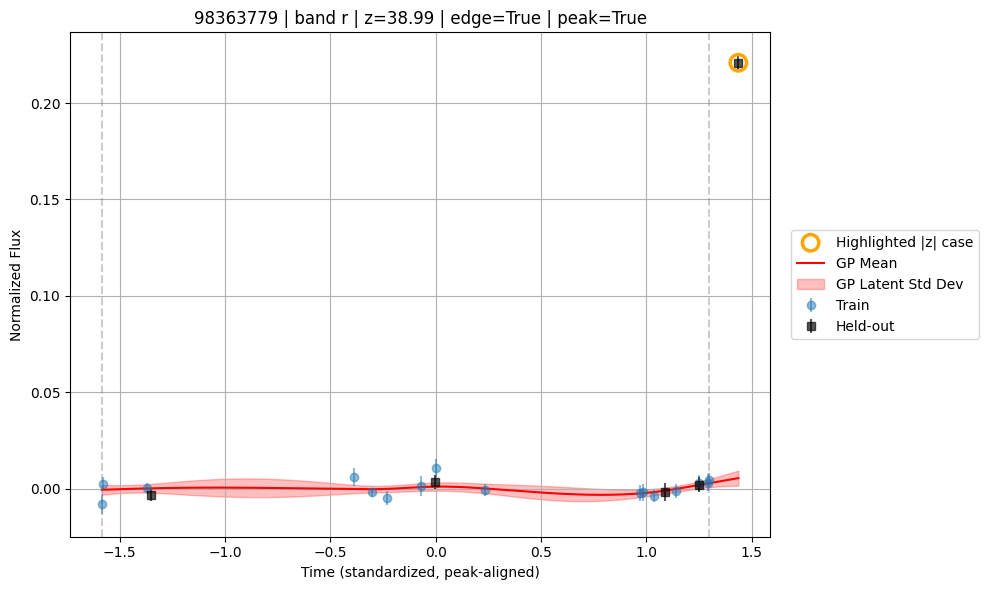

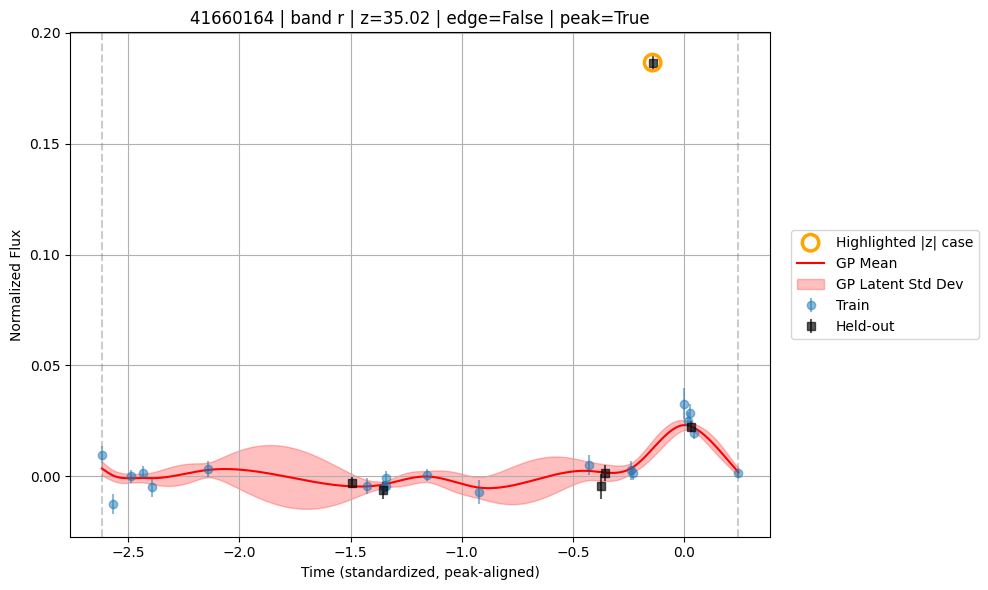

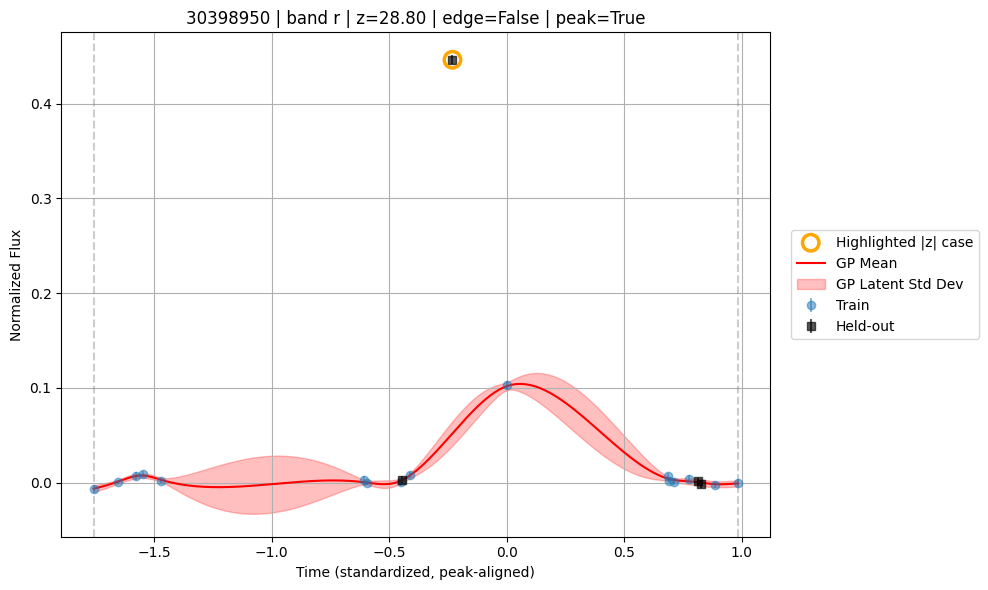

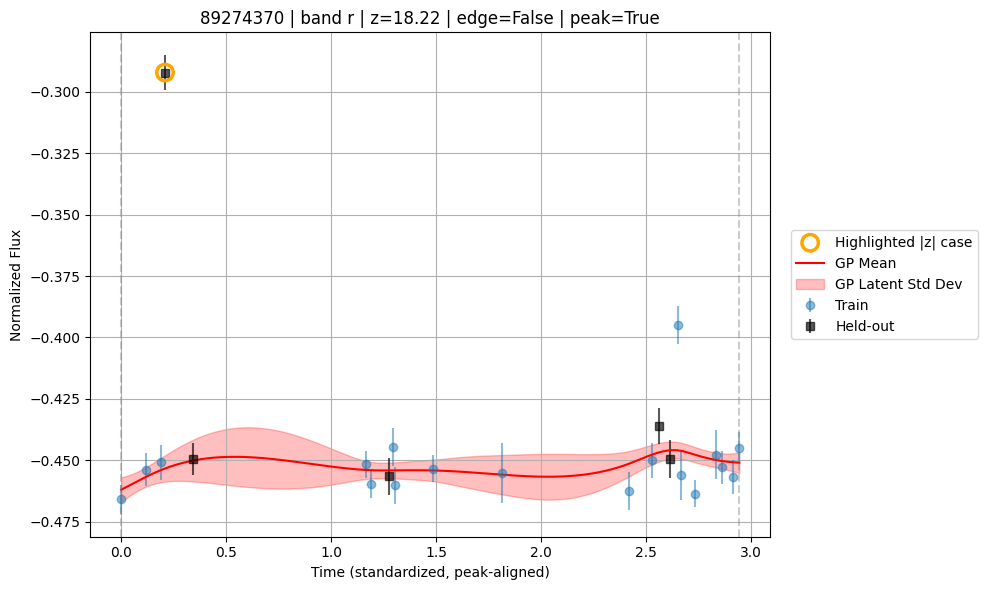

In [6]:
top_cases_by_model = {}

for model_name, results in model_results.items():
    print(f"\n{model_name}")
    cases = print_largest_standardized_residual_cases(results, top_n=10)
    top_cases_by_model[model_name] = cases

# Plot a manageable number first; increase max_plots if you want all 10 per model.
for model_name, results in model_results.items():
    print(f"\nPlots for {model_name}")
    plot_largest_standardized_residual_cases(
        results,
        top_cases_by_model[model_name],
        max_plots=5,
    )


The mean value is around 0, which is fine.

However, all models have too much standardized residual variance, especially Model 2, whereas a calibrated model should have $std(z)~=1$

To conclude:
For many normal observations, predicted intervals are wide enough or slightly too wide.
But for a small number of difficult observations, the model uncertainty is far too small relative to the actual error.

In [5]:
total_objects = 0

for _ in dset_plasticc:
    total_objects += 1

print(total_objects)

7848


# Add Peak Flux to Training Data

Use the global scale for this experiment. No background substraction.

In [7]:
n_objects_target = 300
max_examples_to_scan = 3000
target_band = "r"
global_flux_percentile = 99
min_points = 8
yerr_scale = 1.0
noise_floor = 0.0

selected_examples, flux_scale, scanned_examples = select_examples_and_global_flux_scale(
    iter(dset_plasticc),
    target_band=target_band,
    n_objects=n_objects_target,
    max_examples_to_scan=max_examples_to_scan,
    percentile=global_flux_percentile,
    min_points=min_points,
)

object_results = []
failed_objects = 0

for object_idx, example in enumerate(selected_examples):
    try:
        train_data, heldout_data = process_one_obj_one_band_train_heldout(
            example,
            flux_scale=flux_scale,
            scale_mode="provided",  # use the global flux scale to scale all objects consistently
            target_band=target_band,
            align_peak=True,
            peak_alignment="target_abs_peak",
            peak_mode="absolute",
            force_peak_in_train=True,
            normalize_flux=True,
            min_points=min_points,
            heldout_fraction=0.2,
            min_train_points=5,
            min_heldout_points=1,
            random_state=object_idx,
            strategy="random",
        )
        if train_data is None or heldout_data is None:
            continue

        # fixed length scale to prevent optimization issues
        gp = fit_basic_gp(
            train_data,
            kernel_type="matern",
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )

        metrics = evaluate_heldout_metrics(
            gp,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )
        
        metrics["obj_id"] = train_data["obj_id"]
        metrics["obj_type"] = train_data["obj_type"]
        metrics["gp"] = gp
        metrics["train_data"] = train_data
        metrics["heldout_data"] = heldout_data
        object_results.append(metrics)
        print(train_data["scale_mode"])
        print(train_data["flux_scale"], flux_scale)

    except Exception as err:
        failed_objects += 1
        continue

summary = summarize_object_metric_results(object_results)


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn

provided
868.2722778320312 868.2723


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn

provided
868.2722778320312 868.2723


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.w

provided
868.2722778320312 868.2723


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.w

provided
868.2722778320312 868.2723
provided
868.2722778320312 868.2723


KeyboardInterrupt: 

In [ ]:
print("\nObservation-weighted average")
for metric, value in summary["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")
    
print("\nObject-weighted average")
for metric, value in summary["object_weighted"].items():
    print(f"{metric}: {value:.4f}")



Observation-weighted average
nlpd: 5.0314
rmse: 602.9863
coverage_1sigma: 0.8462
coverage_2sigma: 0.9359
coverage_3sigma: 0.9647

Object-weighted average
nlpd: 5.0258
rmse: 142.0274
coverage_1sigma: 0.8460
coverage_2sigma: 0.9352
coverage_3sigma: 0.9648
provided
868.2722778320312 868.2723


Main diagnosis: including the peak improves NLPD a lot, but does not improve RMSE consistently. That means the model becomes much more confident/probabilistically favorable around important regions, but its mean prediction is not necessarily better.
Random train/test splits can artificially punish GP calibration when the peak is missing from training. Peak-preserving splits produce much better probabilistic calibration, suggesting that extreme light-curve regions dominate uncertainty failure.

# Background Noise Deduction
Estimate new “background” levels for each light curve using a biweight estimator. Substract the estimated constant from the original flux. This approach reduces the influence of outliers and unrelevant factors on data statistics.

In [2]:
import numpy as np

## Model A: global scale without noise reduction

In [3]:
n_objects_target = 300
max_examples_to_scan = 3000
target_band = "r"
global_flux_percentile = 99
min_points = 8
yerr_scale = 1.0
noise_floor = 0.0
from collections import Counter

failure_reasons = Counter()

selected_examples, flux_scale, scanned_examples = select_examples_and_global_flux_scale(
    iter(dset_plasticc),
    target_band=target_band,
    n_objects=n_objects_target,
    max_examples_to_scan=max_examples_to_scan,
    percentile=global_flux_percentile,
    min_points=min_points,
)

object_results = []
failed_objects = 0
debug_printed = 0

for object_idx, example in enumerate(selected_examples):
    try:
        train_data, heldout_data = process_one_obj_one_band_train_heldout(
            example,
            flux_scale=flux_scale,
            target_band=target_band,
            align_peak=True,
            peak_alignment="target_abs_peak",
            peak_mode="absolute",
            force_peak_in_train=True,
            subtract_background=False,
            scale_mode="provided",
            normalize_flux=True,
            min_points=min_points,
            heldout_fraction=0.2,
            min_train_points=5,
            min_heldout_points=1,
            random_state=object_idx,
            strategy="random",
        )
        if train_data is None or heldout_data is None:
            print("skipped object_idx:", object_idx)
            continue

        # fixed length scale to prevent optimization issues
        gp = fit_basic_gp(
            train_data,
            kernel_type="matern",
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )

        metrics = evaluate_heldout_metrics(
            gp,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )
        
        metrics["obj_id"] = train_data["obj_id"]
        metrics["obj_type"] = train_data["obj_type"]
        metrics["gp"] = gp
        metrics["train_data"] = train_data
        metrics["heldout_data"] = heldout_data
        object_results.append(metrics)
        if debug_printed < 5:
            print("object_idx:", object_idx)
            print("scale_mode:", train_data.get("scale_mode"))
            print("flux_scale stored:", train_data["flux_scale"])
            print("global flux_scale:", flux_scale)
            print("background:", train_data.get("background_flux"))
            print("subtract_background:", train_data.get("subtract_background"))
            print("train_indices:", train_data["train_indices"])
            print("heldout_indices:", heldout_data["heldout_indices"])
            print("median yerr norm:", np.median(heldout_data["yerr"]))
            print()
            debug_printed += 1

    except Exception as err:
        failed_objects += 1
        print("failed object_idx:", object_idx, repr(err))
        failure_reasons[f"{type(err).__name__}: {err}"] += 1
        continue

summary = summarize_object_metric_results(object_results)
print(failure_reasons)



/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn

object_idx: 0
scale_mode: provided
flux_scale stored: 868.2722778320312
global flux_scale: 868.2723
background: 0.0
subtract_background: False
train_indices: [ 0  1  2  3  4  6  7  8 10 12 13 15 16 17 18 19]
heldout_indices: [ 5  9 11 14]
median yerr norm: 0.0055209287

object_idx: 1
scale_mode: provided
flux_scale stored: 868.2722778320312
global flux_scale: 868.2723
background: 0.0
subtract_background: False
train_indices: [ 0  1  2  3  4  5  6  9 10 11 13 14 15]
heldout_indices: [ 7  8 12 16]
median yerr norm: 0.0046792813

object_idx: 2
scale_mode: provided
flux_scale stored: 868.2722778320312
global flux_scale: 868.2723
background: 0.0
subtract_background: False
train_indices: [ 0  1  3  5  7  8 10 11 12 13 14 16 17 18 19 20 21 22]
heldout_indices: [ 2  4  6  9 15]
median yerr norm: 0.0037983558

object_idx: 3
scale_mode: provided
flux_scale stored: 868.2722778320312
global flux_scale: 868.2723
background: 0.0
subtract_background: False
train_indices: [ 0  2  5  6  7  8  9 10 11 1

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.w

Counter()


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn

In [4]:
print("\nObservation-weighted average")
for metric, value in summary["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")
    
print("\nObject-weighted average")
for metric, value in summary["object_weighted"].items():
    print(f"{metric}: {value:.4f}")


Observation-weighted average
nlpd: 4.2885
rmse: 291.1707
coverage_1sigma: 0.7646
coverage_2sigma: 0.9356
coverage_3sigma: 0.9707

Object-weighted average
nlpd: 4.3050
rmse: 48.3589
coverage_1sigma: 0.7643
coverage_2sigma: 0.9349
coverage_3sigma: 0.9706


In [5]:
print("n_results:", len(object_results))
print("failed_objects:", failed_objects)
print("summary n_objects:", summary["n_objects"])
print("summary n_heldout_total:", summary["n_heldout_total"])

n_results: 300
failed_objects: 0
summary n_objects: 300
summary n_heldout_total: 1538


Wait!
The scale is not the same with the previous model. In the previous model, the scale is the maximum peak value across all trained objects, which is much higher (around 800) than the current local scale (around 5) used for background noise estimation. Thus the NLPD and RMSE for this model is much higher, while the coverage is not affected. We can either:
1. Transform back to raw flux data, and then compare the NLPD and RMSE.
2. For data in GP, switch to local scale normalization, rather than global scaling. Transform predictions back to raw flux.
Compute NLPD, RMSE/MAE, and plots in raw flux space. Compute z-score/coverage either in raw or normalized space, since they are equivalent if done correctly.


## Local scale with Noise Reduction

In [4]:
n_objects_target = 300
max_examples_to_scan = 3000
target_band = "r"
global_flux_percentile = 99
min_points = 8
yerr_scale = 1.0
noise_floor = 0.0

selected_examples, _, scanned_examples = select_examples_and_global_flux_scale(
    iter(dset_plasticc),
    target_band=target_band,
    n_objects=n_objects_target,
    max_examples_to_scan=max_examples_to_scan,
    percentile=global_flux_percentile,
    min_points=min_points,
)

object_results = []
failed_objects = 0

for object_idx, example in enumerate(selected_examples):
    try:
        train_data, heldout_data = process_one_obj_one_band_train_heldout(
            example,
            flux_scale=None,
            target_band=target_band,
            align_peak=True,
            peak_alignment="target_abs_peak",
            peak_mode="absolute",
            force_peak_in_train=True,
            subtract_background=False,
            scale_mode="local_peak",  # use the global flux scale to scale all objects consistently
            normalize_flux=True,
            min_points=min_points,
            heldout_fraction=0.2,
            min_train_points=5,
            min_heldout_points=1,
            random_state=object_idx,
            strategy="random",
        )
        if train_data is None or heldout_data is None:
            continue

        # fixed length scale to prevent optimization issues
        gp = fit_basic_gp(
            train_data,
            kernel_type="matern",
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )

        metrics = evaluate_heldout_metrics(
            gp,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
            yerr_scale=yerr_scale,
            noise_floor=noise_floor,
        )
        
        metrics["obj_id"] = train_data["obj_id"]
        metrics["obj_type"] = train_data["obj_type"]
        metrics["gp"] = gp
        metrics["train_data"] = train_data
        metrics["heldout_data"] = heldout_data
        object_results.append(metrics)

    except Exception as err:
        failed_objects += 1
        continue

summary = summarize_object_metric_results(object_results)


scale_mode: local_peak
flux_scale stored: 19.99174690246582
global flux_scale: 868.2723
background: 0.0
subtract_background: False
train_indices: [ 0  1  3  5  7  8 10 11 12 13 14 16 17 18 19 20 21 22]
heldout_indices: [ 2  4  6  9 15]
scale_mode: local_peak
flux_scale stored: 5351.39404296875
global flux_scale: 868.2723
background: 0.0
subtract_background: False
train_indices: [ 0  2  5  6  7  8  9 10 11 12 13 15 16 17 18 19 20 21]
heldout_indices: [ 1  3  4 14 22]


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Use

In [7]:
print("\nObservation-weighted average")
for metric, value in summary["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")
    
print("\nObject-weighted average")
for metric, value in summary["object_weighted"].items():
    print(f"{metric}: {value:.4f}")


Observation-weighted average
nlpd: 4.7834
rmse: 544.2341
coverage_1sigma: 0.8593
coverage_2sigma: 0.9521
coverage_3sigma: 0.9731

Object-weighted average
nlpd: 4.7980
rmse: 107.2799
coverage_1sigma: 0.8593
coverage_2sigma: 0.9513
coverage_3sigma: 0.9730


In [ ]:

Observation-weighted average
nlpd: -2.4780
rmse: 0.3353
coverage_1sigma: 0.7646
coverage_2sigma: 0.9356
coverage_3sigma: 0.9707

Object-weighted average
nlpd: -2.4616
rmse: 0.0557
coverage_1sigma: 0.7643
coverage_2sigma: 0.9349
coverage_3sigma: 0.9706